# PyPSA Tutorial

This tutorial connects the optimisation problems we introduced in Lectures 3 and 4 to **PyPSA** — Python for Power System Analysis. This tutorial covers some basic concepts of PyPSA, and accompanies the more hands-on introduction in the [introduction to PyPSA notebook](./introduction-to-pypsa.ipynb).

## 1. Dispatch + Capacity Expansion: Revisiting lecture 3

The core optimisation problem (single node, joint dispatch and capacity expansion) is

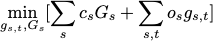

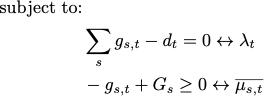

(and further constraints: storage consistency, line limits, etc.)

Each part maps directly to a PyPSA concept:

| Math | Meaning | PyPSA |
|---|---|---|
| $t$ | Each time step (hour) | **Snapshot** |
| one node | System node / representation | **Bus** |
| $d_t$ | Electricity demand | **Load** |
| $g_{s,t}$ | Generator dispatch | **Generator** (result: `n.generators_t.p`) |


Remaining important ingredients:
| Math | Meaning | PyPSA |
|---|---|---|
| $G_s$ | Installed capacity | `p_nom` (fixed) or `p_nom_extendable=True` and `p_nom_opt` |
| $g_{s,t}$ | Capacity factor (wind/solar) | `p_max_pu` time series |
| $c_s$ | Marginal cost | `marginal_cost` |
| $C_s$ | Investment cost | `capital_cost` |
| Energy balance | Demand = Supply | Built into **Bus** automatically |
| Generation limits | Upper bound on dispatch | Built into **Generator** automatically |

## 2. Single-Node Drawing → PyPSA Components

Consider a single-node representation of Denmark (**DK**) with three components:

![PyPSA Network](./dk_pypsa.png)

Each physical element maps to a PyPSA component:

| Drawing symbol | ESM concept | PyPSA component | Notes |
|---|---|---|---|
| Circle `~` with $CF_t$ | Variable generator (wind/solar) | `Generator` | `p_max_pu` = capacity factor time series |
| Box `[+/-]` | Storage | `Store` + `Link` *or* `StorageUnit` | Use `StorageUnit` for fixed E/P ratio (e.g. battery); `Store` for flexible energy capacity |
| Triangle $d_t$ | Demand (load) | `Load` | `p_set` can be constant or a time series |

The **bus** (`Bus`) is the node itself — it enforces the energy balance for everything attached to it.

We want to construct the single-node representation of Denmark in PyPSA, with a wind generator, a battery, and a load. Usually we would start with an empty network and add components one by one, but for "simple" networks there is a nice visual tool that can help us in this:

https://nimabahrami.github.io/pypsa-drawer/

We need to create the following components:
- carriers for AC (for load), wind, and storage
- a bus for DK
- a load for DK
- a generator for DK (wind)
- a storage unit for DK (battery)

We will do this for one day (24 hours), and we will use the real wind capacity factors for Denmark on 2015-01-01 (24 hours) that we introduced in Lecture 3.



DNK wind capacity factors on 2015-01-03:


<Axes: xlabel='utc_time'>

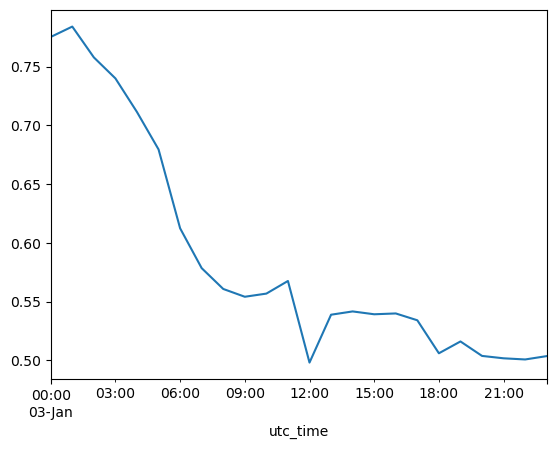

In [85]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt

# --- Real wind capacity factors: Denmark, 2015-01-03 (24 hours) ---
wind = pd.read_csv("Problems/data/onshore_wind.csv", sep=";", index_col=0, parse_dates=True)
wind = wind.tz_convert(None)
wind_dnk = wind.loc["2015-01-03", "DNK"]

print("DNK wind capacity factors on 2015-01-03:")
wind_dnk.plot()

In [86]:
import pypsa
import numpy as np

# Create network
n = pypsa.Network()
n.set_snapshots(range(24))  # Adjust as needed

# --- Carriers ---
n.add(
    "Carrier",
    "Wind",
    co2_emissions=0,
    nice_name="Onshore wind",
    color="0000FF",
)
n.add(
    "Carrier",
    "AC",
    co2_emissions=0,
)
n.add(
    "Carrier",
    "battery",
    co2_emissions=0,
)


# --- Buses ---
n.add(
    "Bus",
    "DK",
    carrier="AC",
)

# --- Generators ---
n.add(
    "Generator",
    "DK wind",
    bus="DK",
    carrier="Wind",
    p_nom=0,
    p_set=0,
    marginal_cost=0,
    capital_cost=101644,
)

# --- Loads ---
n.add(
    "Load",
    "DK load",
    bus="DK",
    carrier="AC",
    p_set=1000,
)

# --- Storage Units ---
n.add(
    "StorageUnit",
    "DK storage",
    bus="DK",
    carrier="battery",
    p_nom=0,
    max_hours=6,
    capital_cost=102042,
    marginal_cost=0,
)

# --- Solve ---
# n.optimize(solver_name="highs")  # Uncomment to solve
# n.statistics()  # View results


We can inspect the network to see what we added:

In [87]:
n

PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 1
 - Carrier: 3
 - Generator: 1
 - Load: 1
 - StorageUnit: 1
Snapshots: 24

We can check which generators we have, its name, its bus and carrier, its current capacity (`p_nom`), its capacity factors (`p_max_pu`), its capital and marginal costs (and other parameters):


In [88]:
n.generators[["bus", "carrier", "p_nom", "p_max_pu", "capital_cost", "marginal_cost"]]

,bus,carrier,p_nom,p_max_pu,capital_cost,marginal_cost
name,,,,,,
DK wind,DK,Wind,0.0,1.0,101644.0,0.0


At this point, we want to add the capacity factors from before, so we will actually regenerate the network similarly, but including snapshots and time series data:

In [94]:
import pypsa
import numpy as np

# Create network
n = pypsa.Network()
n.set_snapshots(wind_dnk.index)  # NOTE THE DIFFERENCE

# --- Carriers ---
n.add(
    "Carrier",
    "Wind",
    co2_emissions=0,
    nice_name="Onshore wind",
    color="0000FF",
)
n.add(
    "Carrier",
    "AC",
    co2_emissions=0,
)
n.add(
    "Carrier",
    "battery",
    co2_emissions=0,
    color ="FF0000",
)


# --- Buses ---
n.add(
    "Bus",
    "DK",
    carrier="AC",
)

# --- Generators ---
n.add(
    "Generator",
    "DK wind",
    bus="DK",
    carrier="Wind",
    p_nom=0,
    p_set=0,
    marginal_cost=0,
    capital_cost=101644,
    p_max_pu=wind_dnk.values, # NOTE THE DIFFERENCE
    p_nom_extendable=True, # Allow capacity expansion
)

# --- Loads ---
n.add(
    "Load",
    "DK load",
    bus="DK",
    p_set=pd.Series(1000, index=wind_dnk.index),  # NOTE THE DIFFERENCE
)

# --- Storage Units ---
n.add(
    "StorageUnit",
    "DK storage",
    bus="DK",
    carrier="battery",
    p_nom=0,
    max_hours=6,
    capital_cost=102042,
    marginal_cost=0,
    p_nom_extendable=True,  # Allow capacity expansion
)

In [95]:
n.generators[["bus", "carrier", "p_nom", "p_max_pu", "capital_cost", "marginal_cost"]]

,bus,carrier,p_nom,p_max_pu,capital_cost,marginal_cost
name,,,,,,
DK wind,DK,Wind,0.0,1.0,101644.0,0.0


We can now check whether the capacity factors were added correctly:

In [96]:
n.generators_t.p_max_pu

name,DK wind
snapshot,
2015-01-03 00:00:00,0.775336
2015-01-03 01:00:00,0.784170
2015-01-03 02:00:00,0.757938
2015-01-03 03:00:00,0.740065
2015-01-03 04:00:00,0.711429
2015-01-03 05:00:00,0.679621
2015-01-03 06:00:00,0.612471
2015-01-03 07:00:00,0.578539
2015-01-03 08:00:00,0.560825


Same for the load:

In [97]:
n.loads_t.p_set

name,DK load
snapshot,
2015-01-03 00:00:00,1000.0
2015-01-03 01:00:00,1000.0
2015-01-03 02:00:00,1000.0
2015-01-03 03:00:00,1000.0
2015-01-03 04:00:00,1000.0
2015-01-03 05:00:00,1000.0
2015-01-03 06:00:00,1000.0
2015-01-03 07:00:00,1000.0
2015-01-03 08:00:00,1000.0


In [110]:
n.storage_units_t.p

name,DK storage
snapshot,
2015-01-03 00:00:00,-76.222690
2015-01-03 01:00:00,-76.222690
2015-01-03 02:00:00,-76.222690
2015-01-03 03:00:00,-76.222690
2015-01-03 04:00:00,-76.222690
2015-01-03 05:00:00,-76.222690
2015-01-03 06:00:00,0.000000
2015-01-03 07:00:00,0.000000
2015-01-03 08:00:00,0.000000


In [111]:
n.optimize(solver_name="gurobi")  # Solve


INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io: Writing time: 0.04s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2767832


INFO:gurobipy:Set parameter LicenseID to value 2767832


...

Solved in 49 iterations and 0.01 seconds (0.00 work units)


INFO:gurobipy:Solved in 49 iterations and 0.01 seconds (0.00 work units)


Optimal objective  1.962651445e+08


INFO:gurobipy:Optimal objective  1.962651445e+08
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 98 primals, 242 duals
Objective: 1.96e+08
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

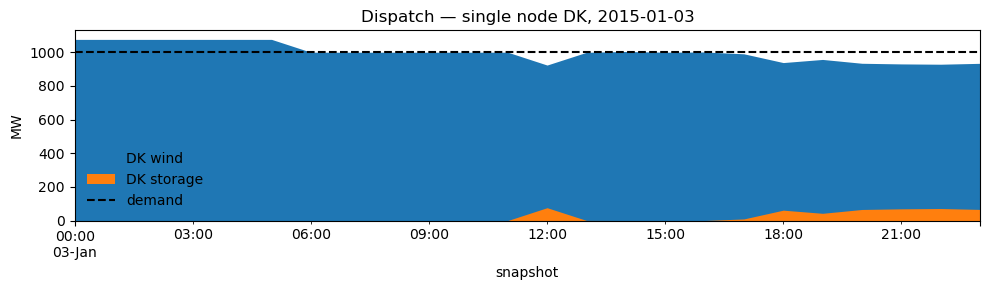

In [120]:
# n.statistics.energy_balance(groupby_time=False)

# # Stack plot, including charge and discharge.

# fig, ax = plt.subplots(figsize=(10, 3))
   

/opt/homebrew/Caskroom/miniforge/base/envs/integrated-energy-grids/lib/python3.13/site-packages/pandas/plotting/_matplotlib/core.py:1800: UserWarning:

Attempting to set identical low and high ylims makes transformation singular; automatically expanding.



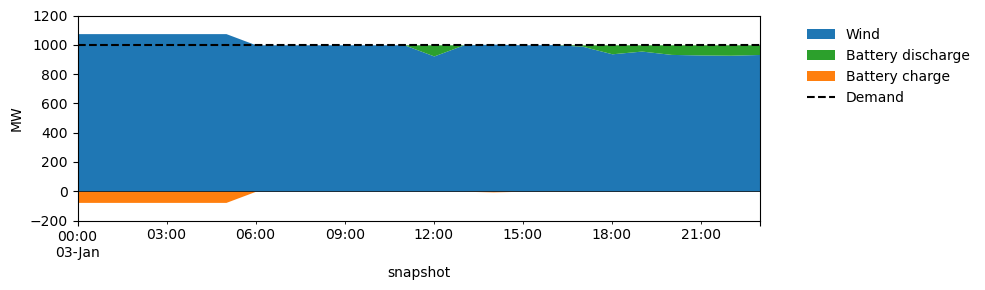

In [136]:
import pandas as pd

fig, ax = plt.subplots(figsize=(10, 3))

bat_dis = n.storage_units_t.p.clip(lower=0)  # positive: discharge
bat_ch  = n.storage_units_t.p.clip(upper=0)  # negative: charging

# Stack wind + OCGT + battery discharge together above 0
supply = pd.concat([
    n.generators_t.p.rename(columns={"DK wind": "Wind"}),
    bat_dis.rename(columns={"DK storage": "Battery discharge"}),
], axis=1)
supply.plot.area(ax=ax, linewidth=0, stacked=True,
                 color=["#1f77b4", "#2ca02c"])

# Battery charging below 0 (separate call is fine here — it naturally starts from 0 and goes negative)
bat_ch.rename(columns={"DK storage": "Battery charge"}).plot.area(
    ax=ax, linewidth=0, stacked=True, color=["#ff7f0e"])

# Demand
n.loads_t.p_set.sum(axis=1).plot(ax=ax, color="black", linestyle="--", label="Demand")

ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("MW")
ax.set_ylim(-200, 1200)
ax.legend(frameon=False, bbox_to_anchor=(1.05, 1))
plt.tight_layout()


## 3. Two Nodes: DK and DE

![PyPSA Network](./deu-dnk.png)

Each physical element maps to a PyPSA component:

| Drawing symbol | ESM concept | PyPSA component | Notes |
|---|---|---|---|
| Circle `~` with $CF_t$ | Variable generator (wind/solar) | `Generator` | `p_max_pu` = capacity factor time series |
| Box `[+/-]` | Storage | `Store` + `Link` *or* `StorageUnit` | Use `StorageUnit` for fixed E/P ratio (e.g. battery); `Store` for flexible energy capacity |
| Triangle $d_t$ | Demand (load) | `Load` | `p_set` can be constant or a time series |
| **Line AC** | AC transmission with KVL | `Line` | Meshed grids, requires reactance `x`; linearised power flow |

The energy balance now holds **at each bus separately**:

$$\sum_s g_{i,s,t} + f_{\ell,t} = d_{i,t} \qquad \forall i \in \{\text{DK, DE}\},\; \forall t$$

where $f_{\ell,t}$ is the net power injected at bus $i$ from the line (positive = import, negative = export), subject to

$$|f_{\ell,t}| \leq F_\ell$$

PyPSA writes both constraints automatically from the network topology. You only need to specify which bus each component is attached to.

DNK, DEU wind capacity factors on 2015-01-03:


<Axes: xlabel='utc_time'>

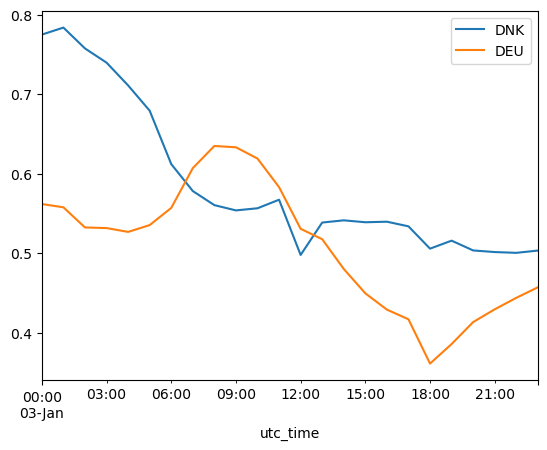

In [137]:
# --- Real wind capacity factors: Denmark, 2015-01-03 (24 hours) ---
wind = pd.read_csv("Problems/data/onshore_wind.csv", sep=";", index_col=0, parse_dates=True)
wind = wind.tz_convert(None)
wind_dnk_deu = wind.loc["2015-01-03", ["DNK", "DEU"]]

print("DNK, DEU wind capacity factors on 2015-01-03:")
wind_dnk_deu.plot()

In [160]:
import pypsa
import numpy as np

# Create network
n = pypsa.Network()
n.set_snapshots(wind_dnk_deu.index)  # Adjust as needed

# --- Carriers ---
n.add(
    "Carrier",
    "Wind",
    co2_emissions=0,
    nice_name="Onshore wind",
    color="0000FF",
)
n.add(
    "Carrier",
    "AC",
    co2_emissions=0,
)
n.add(
    "Carrier",
    "battery",
    co2_emissions=0,
    color="FF0000",
)

# --- Buses ---
n.add(
    "Bus",
    "DK",
    carrier="AC",
)
n.add(
    "Bus",
    "DE",
    carrier="AC",
)

# --- Generators ---
n.add(
    "Generator",
    "DK wind",
    bus="DK",
    carrier="Wind",
    p_nom=0,
    p_nom_extendable=True,
    p_max_pu=wind_dnk_deu["DNK"].values,
    p_set=0,
    marginal_cost=0,
    capital_cost=101644,
)
n.add(
    "Generator",
    "DE wind",
    bus="DE",
    carrier="Wind",
    p_nom=0,
    p_nom_extendable=True,
    p_max_pu=wind_dnk_deu["DEU"].values,
    p_set=0,
    marginal_cost=0,
    capital_cost=101644,
)

# --- Loads ---
n.add(
    "Load",
    "DK load",
    bus="DK",
    p_set=pd.Series(1000, index=wind_dnk_deu.index),  # NOTE THE DIFFERENCE
)
n.add(
    "Load",
    "DE load",
    bus="DE",
    p_set=pd.Series(5000, index=wind_dnk_deu.index),  # NOTE THE DIFFERENCE
)

# --- Storage Units ---
n.add(
    "StorageUnit",
    "DK storage",
    bus="DK",
    carrier="battery",
    p_nom=0,
    p_nom_extendable=True,
    max_hours=6,
    capital_cost=102042,
    marginal_cost=0,
)
n.add(
    "StorageUnit",
    "DE storage",
    bus="DE",
    carrier="battery",
    p_nom=0,
    max_hours=6,
    capital_cost=102042,
    marginal_cost=0,
    p_nom_extendable=True,  # Allow capacity expansion
)

# --- Lines ---
n.add(
    "Line",
    "DK-DE",
    bus0="DK",
    bus1="DE",
    x=0,
    s_nom=1500,
)



In [161]:
n.optimize(solver_name="gurobi")

Index(['DK-DE'], dtype='object', name='name')
Index(['DK-DE'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io: Writing time: 0.04s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2767832


INFO:gurobipy:Set parameter LicenseID to value 2767832


...

Solved in 187 iterations and 0.01 seconds (0.00 work units)


INFO:gurobipy:Solved in 187 iterations and 0.01 seconds (0.00 work units)


Optimal objective  1.283971973e+09


INFO:gurobipy:Optimal objective  1.283971973e+09
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 220 primals, 532 duals
Objective: 1.28e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

<Axes: ylabel='component,bus,carrier'>

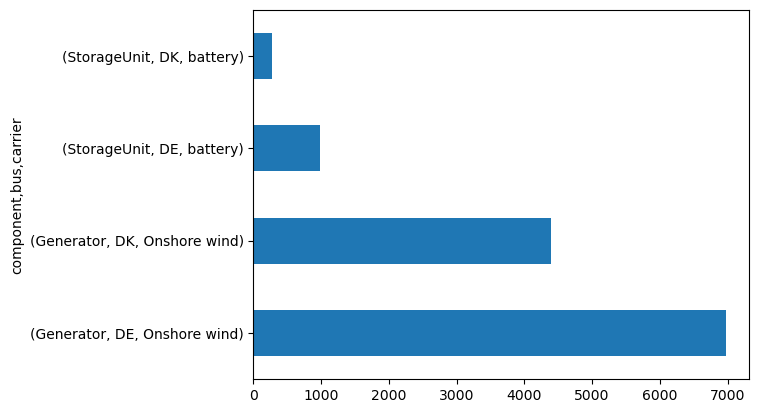

In [175]:
n.statistics.optimal_capacity(components=["Generator", "StorageUnit"], groupby=["bus", "carrier"]).plot(kind="barh")

In [162]:
n.statistics.optimal_capacity(groupby=["bus", "carrier"])

component    bus  carrier     
Generator    DE   Onshore wind    6974.65393
             DK   Onshore wind    4401.21892
Line         DK   AC              1500.00000
StorageUnit  DE   battery          978.62773
             DK   battery          272.64874
dtype: float64

In [167]:
n.statistics.supply()

component    carrier     
Generator    Onshore wind    144000.00000
Line         AC               34887.96337
StorageUnit  battery           7600.22490
dtype: float64

In [177]:
n.statistics.supply(groupby=["bus"])

component    bus
Generator    DE     85112.03663
             DK     58887.96337
Line         DE     34887.96337
StorageUnit  DE      5871.76640
             DK      1728.45850
dtype: float64

In [179]:
n.statistics.withdrawal(groupby=["bus"])

component    bus
Line         DK      34887.96337
Load         DE     120000.00000
             DK      24000.00000
StorageUnit  DE       5871.76640
             DK       1728.45850
dtype: float64

In [180]:
n.statistics.capacity_factor(components=["Generator", "StorageUnit", "Line"], groupby=["bus", "carrier"])

component    bus  carrier     
Generator    DE   Onshore wind    0.508460
             DK   Onshore wind    0.557497
StorageUnit  DE   battery         0.500000
             DK   battery         0.528292
Line         DK   AC              0.969110
dtype: float64

In [163]:
n.statistics.curtailment(groupby=["bus", "carrier"])

component    bus  carrier     
Generator    DK   Onshore wind     3185.08535
StorageUnit  DE   battery         23487.06559
             DK   battery          6543.56965
dtype: float64

In [159]:
n.statistics.energy_balance(groupby="bus", groupby_time=False)

snapshot         2015-01-03 00:00:00  2015-01-03 01:00:00  \
component   bus                                             
Generator   DE                   NaN                  NaN   
            DK            6457.33614           5542.66386   
Line        DK           -5457.33614          -4542.66386   
            DE            5457.33614           4542.66386   
Load        DE           -5000.00000          -5000.00000   
            DK           -1000.00000          -1000.00000   
StorageUnit DE            -457.33614            457.33614   
            DK                   NaN                  NaN   

snapshot         2015-01-03 02:00:00  2015-01-03 03:00:00  \
component   bus                                             
Generator   DE                   NaN                  NaN   
            DK                6000.0           6017.44607   
Line        DK               -5000.0          -5017.44607   
            DE                5000.0           5017.44607   
Load        DE               -5000.0          -5000.00000   
            DK               -1000.0          -1000.00000   
StorageUnit DE                   NaN            -17.44607   
            DK                   NaN                  NaN   

snapshot         2015-01-03 04:00:00  2015-01-03 05:00:00  \
component   bus                                             
Generator   DE                   NaN                  NaN   
            DK            6457.33614           6457.33614   
Line        DK           -5457.33614          -5457.33614   
            DE            5457.33614           5457.33614   
Load        DE           -5000.00000          -5000.00000   
            DK           -1000.00000          -1000.00000   
StorageUnit DE            -457.33614           -457.33614   
            DK                   NaN                  NaN   

snapshot         2015-01-03 06:00:00  2015-01-03 07:00:00  \
component   bus                                             
Generator   DE                   NaN                  NaN   
            DK            6457.33614           6437.00836   
Line        DK           -5457.33614          -5437.00836   
            DE            5457.33614           5437.00836   
Load        DE           -5000.00000          -5000.00000   
            DK           -1000.00000          -1000.00000   
StorageUnit DE            -457.33614           -437.00836   
            DK                   NaN                  NaN   

snapshot         2015-01-03 08:00:00  2015-01-03 09:00:00  ...  \
component   bus                                            ...   
Generator   DE                   NaN                  NaN  ...   
            DK            6239.91678           6166.11591  ...   
Line        DK           -5239.91678          -5166.11591  ...   
            DE            5239.91678           5166.11591  ...   
Load        DE           -5000.00000          -5000.00000  ...   
            DK           -1000.00000          -1000.00000  ...   
StorageUnit DE            -239.91678           -166.11591  ...   
            DK                   NaN                  NaN  ...   

snapshot         2015-01-03 14:00:00  2015-01-03 15:00:00  \
component   bus                                             
Generator   DE                   NaN                  NaN   
            DK            6027.13709           6000.23365   
Line        DK           -5027.13709          -5000.23365   
            DE            5027.13709           5000.23365   
Load        DE           -5000.00000          -5000.00000   
            DK           -1000.00000          -1000.00000   
StorageUnit DE             -27.13709             -0.23365   
            DK                   NaN                  NaN   

snapshot         2015-01-03 16:00:00  2015-01-03 17:00:00  \
component   bus                                             
Generator   DE                   NaN                  NaN   
            DK             6007.9887           5943.24466   
Line        DK            -5007.9887    

In [166]:
n.statistics.transmission(groupby_time=False)

,snapshot,2015-01-03 00:00:00,2015-01-03 01:00:00,2015-01-03 02:00:00,2015-01-03 03:00:00,2015-01-03 04:00:00,2015-01-03 05:00:00,2015-01-03 06:00:00,2015-01-03 07:00:00,2015-01-03 08:00:00,2015-01-03 09:00:00,...,2015-01-03 14:00:00,2015-01-03 15:00:00,2015-01-03 16:00:00,2015-01-03 17:00:00,2015-01-03 18:00:00,2015-01-03 19:00:00,2015-01-03 20:00:00,2015-01-03 21:00:00,2015-01-03 22:00:00,2015-01-03 23:00:00
component,carrier,,,,,,,,,,,,,,,,,,,,,
Line,AC,1500.0,1500.0,1500.0,1500.0,1500.0,1500.0,1500.0,1500.0,1500.0,1500.0,...,1500.0,1500.0,1500.0,1500.0,1500.0,1328.6746,1490.11486,1335.57677,1476.83198,1216.74873


In [182]:
n.statistics.system_cost()

component    carrier     
Generator    Onshore wind    1.156289e+09
StorageUnit  battery         1.276828e+08
dtype: float64

In [184]:
n.statistics.capex()

component    carrier     
Generator    Onshore wind    1.156289e+09
StorageUnit  battery         1.276828e+08
dtype: float64

In [185]:
n.statistics.revenue()

component    carrier     
Generator    Onshore wind    1.156289e+09
Line         AC              4.713123e+07
Load         -              -1.331103e+09
StorageUnit  battery         1.276828e+08
dtype: float64

## 6. PyPSA Architecture: Inputs → Model → Optimisation → Analysis

```
  Inputs (pandas)                          constraints
  - weather / capacity factors             by default
  - costs, tech parameters   ──────►  Mathematical model  ──────►  Optimisation  ──────►  Optimal    ──────►  Analysis
                                       of an energy network        problem                 system              (pandas)
  Inputs (networkX topology)                                        Gurobi / HiGHS
  - buses, links, lines       ──────►                              via linopy
                                                                    (n.model)
                                                                         │
                                                               n.pf()   n.lpf()
```

- **`pandas`** carries all time-series and static data (capacity factors, demand, costs).  
- **`networkX`**-style topology is encoded in `n.buses`, `n.lines`, `n.links`, etc.  
- PyPSA translates your network description into a **linopy** `Model` object (`n.model`).  
- The solver (Gurobi or HiGHS) solves the LP/MILP and results land back in pandas DataFrames.  
- `n.pf()` (full AC) and `n.lpf()` (linearised DC) are available for power flow analysis after dispatch is fixed.  

### Step 1 — Create the model (without solving)

This lets you inspect the decision variables and constraints before handing off to the solver.

In [ ]:
n.optimize.create_model()

m = n.model
print(m)

Index(['DK1', 'DK2'], dtype='object', name='name')
Index(['DK1-DK2 HVDC'], dtype='object', name='name')


Linopy LP model

Variables:
----------
 * Generator-p (snapshot, name)
 * Link-p (snapshot, name)

Constraints:
------------
 * Generator-fix-p-lower (snapshot, name)
 * Generator-fix-p-upper (snapshot, name)
 * Link-fix-p-lower (snapshot, name)
 * Link-fix-p-upper (snapshot, name)
 * Bus-nodal_balance (name, snapshot)

Status:
-------
initialized


In [ ]:
# All decision variables
m.variables

linopy.model.Variables
----------------------
 * Generator-p (snapshot, name)
 * Link-p (snapshot, name)

In [ ]:
# Generator dispatch variable: shape = (snapshots × generators)
m['Generator-p']

Variable (snapshot: 168, name: 4)
---------------------------------
[2025-01-06 00:00:00, DK1 wind]: Generator-p[2025-01-06 00:00:00, DK1 wind] ∈ [-inf, inf]
[2025-01-06 00:00:00, DK2 wind]: Generator-p[2025-01-06 00:00:00, DK2 wind] ∈ [-inf, inf]
[2025-01-06 00:00:00, DK1 OCGT]: Generator-p[2025-01-06 00:00:00, DK1 OCGT] ∈ [-inf, inf]
[2025-01-06 00:00:00, DK2 OCGT]: Generator-p[2025-01-06 00:00:00, DK2 OCGT] ∈ [-inf, inf]
[2025-01-06 01:00:00, DK1 wind]: Generator-p[2025-01-06 01:00:00, DK1 wind] ∈ [-inf, inf]
[2025-01-06 01:00:00, DK2 wind]: Generator-p[2025-01-06 01:00:00, DK2 wind] ∈ [-inf, inf]
[2025-01-06 01:00:00, DK1 OCGT]: Generator-p[2025-01-06 01:00:00, DK1 OCGT] ∈ [-inf, inf]
		...
[2025-01-12 22:00:00, DK2 wind]: Generator-p[2025-01-12 22:00:00, DK2 wind] ∈ [-inf, inf]
[2025-01-12 22:00:00, DK1 OCGT]: Generator-p[2025-01-12 22:00:00, DK1 OCGT] ∈ [-inf, inf]
[2025-01-12 22:00:00, DK2 OCGT]: Generator-p[2025-01-12 22:00:00, DK2 OCGT] ∈ [-inf, inf]
[2025-01-12 23:00:00, DK1 

In [ ]:
# All automatically generated constraints
m.constraints

linopy.model.Constraints
------------------------
 * Generator-fix-p-lower (snapshot, name)
 * Generator-fix-p-upper (snapshot, name)
 * Link-fix-p-lower (snapshot, name)
 * Link-fix-p-upper (snapshot, name)
 * Bus-nodal_balance (name, snapshot)

In [ ]:
# Nodal energy balance — one equation per bus per snapshot
m.constraints['Bus-nodal_balance']

Constraint `Bus-nodal_balance` [name: 2, snapshot: 168]:
--------------------------------------------------------
[DK1, 2025-01-06 00:00:00]: +1 Generator-p[2025-01-06 00:00:00, DK1 wind] + 1 Generator-p[2025-01-06 00:00:00, DK1 OCGT] - 1 Link-p[2025-01-06 00:00:00, DK1-DK2 HVDC]    = 6000.0
[DK1, 2025-01-06 01:00:00]: +1 Generator-p[2025-01-06 01:00:00, DK1 wind] + 1 Generator-p[2025-01-06 01:00:00, DK1 OCGT] - 1 Link-p[2025-01-06 01:00:00, DK1-DK2 HVDC]    = 6000.0
[DK1, 2025-01-06 02:00:00]: +1 Generator-p[2025-01-06 02:00:00, DK1 wind] + 1 Generator-p[2025-01-06 02:00:00, DK1 OCGT] - 1 Link-p[2025-01-06 02:00:00, DK1-DK2 HVDC]    = 6000.0
[DK1, 2025-01-06 03:00:00]: +1 Generator-p[2025-01-06 03:00:00, DK1 wind] + 1 Generator-p[2025-01-06 03:00:00, DK1 OCGT] - 1 Link-p[2025-01-06 03:00:00, DK1-DK2 HVDC]    = 6000.0
[DK1, 2025-01-06 04:00:00]: +1 Generator-p[2025-01-06 04:00:00, DK1 wind] + 1 Generator-p[2025-01-06 04:00:00, DK1 OCGT] - 1 Link-p[2025-01-06 04:00:00, DK1-DK2 HVDC]    

### Step 2 — Solve

In [ ]:
n.optimize.solve_model(solver_name='gurobi')
# Equivalent shorthand: n.optimize(solver_name='gurobi')

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io: Writing time: 0.15s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2767832


INFO:gurobipy:Set parameter LicenseID to value 2767832


...

Solved in 0 iterations and 0.01 seconds (0.00 work units)


INFO:gurobipy:Solved in 0 iterations and 0.01 seconds (0.00 work units)


Infeasible or unbounded model


INFO:gurobipy:Infeasible or unbounded model
Status: warning
Termination condition: infeasible_or_unbounded
Solution: 0 primals, 0 duals
Objective: nan
Solver model: available
Solver message: 4



('warning', 'infeasible_or_unbounded')

### Step 3 — Retrieve results (pandas)

In [ ]:
print("Generator dispatch [MW] — first 6 snapshots:")
print(n.generators_t.p.iloc[:6].round(1))

print("\nLink flow DK→DE [MW] — first 6 snapshots:")
print(n.links_t.p0.iloc[:6].round(1))

print("\nMarginal prices [EUR/MWh] — first 6 snapshots:")
print(n.buses_t.marginal_price.iloc[:6].round(2))

# Interpretation:
# - 0 EUR/MWh: wind curtailed (excess supply)
# - 65 EUR/MWh: OCGT is the marginal generator

### `n.pf()` and `n.lpf()`

| Method | Physics | When to use |
|---|---|---|
| `n.pf()` | Full AC (Newton–Raphson): voltages, reactive power, line loading | Lecture 5 — OPF; detailed operations |
| `n.lpf()` | Linearised DC: active power only | What `n.optimize()` uses internally; fast |

```python
n.pf()              # requires dispatch to be fixed first
n.buses_t.v_mag_pu  # voltage magnitudes
n.lines_t.p0        # active power flows
```

## 7. Statistics and Plotting

`n.statistics` provides a consistent pandas-based API for post-processing. All methods accept `groupby`, `components`, and `carrier` filters.

In [186]:
n.statistics()

,,Optimal Capacity,Installed Capacity,Supply,Withdrawal,Energy Balance,Transmission,Capacity Factor,Curtailment,Capital Expenditure,Operational Expenditure,Revenue,Market Value
Generator,Onshore wind,11375.87284,0.0,144000.0000,0.00000,144000.00000,0.00000,0.527432,3185.08535,1.156289e+09,0.0,1.156289e+09,8029.786244
Line,AC,1500.00000,1500.0,0.0000,34887.96337,-34887.96337,34887.96337,0.969110,0.00000,0.000000e+00,0.0,-2.795126e+08,NaN
Load,-,0.00000,0.0,0.0000,144000.00000,-144000.00000,0.00000,NaN,0.00000,0.000000e+00,0.0,-1.331103e+09,NaN
StorageUnit,battery,1251.27647,0.0,7600.2249,7600.22490,0.00000,0.00000,0.506165,30030.63524,1.276828e+08,0.0,1.276828e+08,16799.865010


In [ ]:
print('Operational costs [EUR]:')
print(n.statistics.opex())

print('\nCapacity factors:')
print(n.statistics.capacity_factor(comps=['Generator']).round(3))

print('\nEnergy supply [MWh]:')
print(n.statistics.supply(comps=['Generator']).round(0))

Operational costs [EUR]:
Series([], dtype: float64)

Capacity factors:


TypeError: Expected numeric dtype, got object instead.

### Dispatch area plot

In [ ]:
p_by_carrier = (
    n.generators_t.p
    .T.groupby(n.generators.carrier).sum().T / 1_000  # GW
)

fig, ax = plt.subplots(figsize=(12, 4))
colors = [n.carriers.color.get(c, 'grey') for c in p_by_carrier.columns]
p_by_carrier.plot(kind='area', ax=ax, linewidth=0, color=colors)

(n.loads_t.p_set.sum(axis=1) / 1_000).plot(
    ax=ax, color='black', linewidth=1.5, linestyle='--', label='Total demand')

ax.set_ylabel('Power [GW]')
ax.set_title('Dispatch by carrier — one week')
ax.legend(frameon=False)
plt.tight_layout()

### Marginal prices

In [ ]:
fig, ax = plt.subplots(figsize=(12, 3))
n.buses_t.marginal_price.plot(ax=ax)
ax.set_ylabel('EUR/MWh')
ax.set_title('Locational marginal prices')
ax.legend(frameon=False)
plt.tight_layout()

### Network map

In [ ]:
import cartopy.crs as ccrs

dispatch = (
    n.generators_t.p.mean()
    .groupby([n.generators.bus, n.generators.carrier]).sum()
)

fig = plt.figure(figsize=(5, 5))
ax = plt.axes(projection=ccrs.EqualEarth())
n.plot(ax=ax, bus_sizes=dispatch / 3_000, margin=3,
       title='Average dispatch — pie per bus')
plt.tight_layout()

### Further reading

- [PyPSA documentation](https://pypsa.readthedocs.io)  
- Statistics API: `n.statistics.capex()`, `n.statistics.market_value()`, `n.statistics.curtailment()`  
- Large-scale studies: [PyPSA-Eur](https://pypsa-eur.readthedocs.io)  